Daily Challenge: Building Your First Neural Network on the MNIST Dataset

1. Charger et Prétraiter le Dataset MNIST : Préparer les Données pour le Modèle

In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Version de TensorFlow pour bonne prise en charge
print("TensorFlow Version:", tf.__version__)

# --- Upload dataset MNIST ---
# Données_entraînement, labels_entraînement et données_test, labels_test
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

TensorFlow Version: 2.18.0


In [5]:
# Analyse des dimensions des données
print(f"\nDimension des données d'entraînement complètes (images, hauteur, largeur) : {X_train_full.shape}")
print(f"Dimension des labels d'entraînement complets : {y_train_full.shape}")
print(f"Dimension des données de test : {X_test.shape}")
print(f"Dimension des labels de test : {y_test.shape}")



Dimension des données d'entraînement complètes (images, hauteur, largeur) : (60000, 28, 28)
Dimension des labels d'entraînement complets : (60000,)
Dimension des données de test : (10000, 28, 28)
Dimension des labels de test : (10000,)


In [6]:


# Chaque pixel est représenté par un nombre entre 0 et 255 (intensité lumineuse)
print(f"\nType de données des pixels avant normalisation : {X_train_full.dtype}")
print(f"Valeur minimale des pixels avant normalisation : {np.min(X_train_full)}")
print(f"Valeur maximale des pixels avant normalisation : {np.max(X_train_full)}")


Type de données des pixels avant normalisation : uint8
Valeur minimale des pixels avant normalisation : 0
Valeur maximale des pixels avant normalisation : 255


In [7]:
# --- Normalisation des valeurs de pixel entre 0 et 1 ---

# Stabilité et Performance
# Division simplement par 255 (la valeur maximale d'un pixel)
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

print(f"\nValeur minimale des pixels après normalisation : {np.min(X_train_full)}")
print(f"Valeur maximale des pixels après normalisation : {np.max(X_train_full)}")


Valeur minimale des pixels après normalisation : 0.0
Valeur maximale des pixels après normalisation : 1.0


In [8]:
# --- Diviser le dataset d'entraînement en entraînement et validation ---
# L'ensemble d'entraînement "full" est trop grand pour valider le modèle après chaque "epoch".
# Un ensemble de validation va surveiller les performances du modèle pendant l'entraînement vs surapprentissage (overfitting).
# Sur les 5000 premières images pour la validation.
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

print(f"\nDimension des données d'entraînement réelles : {X_train.shape}")
print(f"Dimension des labels d'entraînement réels : {y_train.shape}")
print(f"Dimension des données de validation : {X_valid.shape}")
print(f"Dimension des labels de validation : {y_valid.shape}")


Dimension des données d'entraînement réelles : (55000, 28, 28)
Dimension des labels d'entraînement réels : (55000,)
Dimension des données de validation : (5000, 28, 28)
Dimension des labels de validation : (5000,)


In [9]:
# --- Convertir les labels en format "one-hot encoded" ---
# Pour la classification multi-classes, les réseaux de neurones ne fonctionnent pas bien avec des labels comme 0, 1, 2...
# Ils ont besoin d'un vecteur binaire où une seule position est "chaude" (1) et les autres "froides" (0).
# Exemple : Le chiffre 5 devient [0, 0, 0, 0, 0, 1, 0, 0, 0, 0] pour 10 classes.
y_train_one_hot = keras.utils.to_categorical(y_train, num_classes=10)
y_valid_one_hot = keras.utils.to_categorical(y_valid, num_classes=10)
y_test_one_hot = keras.utils.to_categorical(y_test, num_classes=10) # Préparez aussi les labels de test

print(f"\nPremier label d'entraînement (avant one-hot) : {y_train[0]}")
print(f"Premier label d'entraînement (après one-hot) : {y_train_one_hot[0]}")


Premier label d'entraînement (avant one-hot) : 7
Premier label d'entraînement (après one-hot) : [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


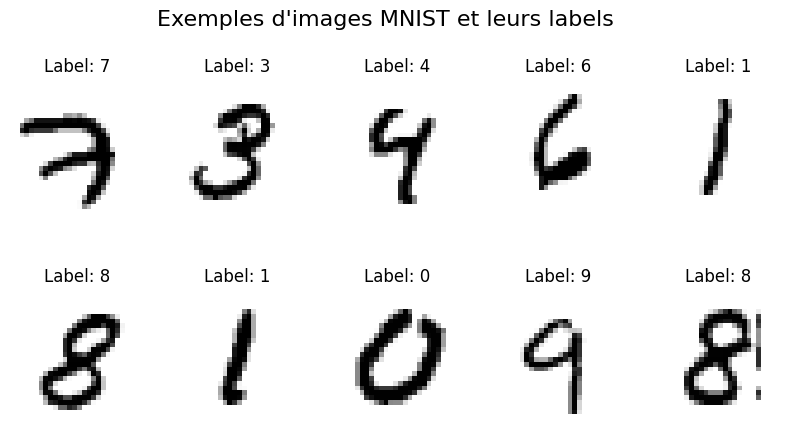

In [10]:
# --- Afficher des exemples d'images avec leurs labels ---
plt.figure(figsize=(10, 5)) # Définit la taille de la figure
for i in range(10): # Boucle pour afficher 10 images
    plt.subplot(2, 5, i + 1) # Crée une grille de 2 lignes et 5 colonnes pour les images
    plt.imshow(X_train[i], cmap='binary') # Affiche l'image en noir et blanc (cmap='binary')
    plt.title(f"Label: {y_train[i]}") # Affiche le label original sous l'image
    plt.axis('off') # Cache les axes pour un affichage plus propre
plt.suptitle("Exemples d'images MNIST et leurs labels", fontsize=16) # Titre général
plt.show() # Affiche la figure

In [11]:
# --- Définir le modèle séquentiel ---
#  Modèle Sequential : façon la plus simple de construire un réseau de neurones couche par couche.
model = keras.models.Sequential([
    # 1. Couche d'aplatissement (Flatten)
    # Les images MNIST sont 28x28 pixels. Un réseau dense s'attend à un vecteur 1D en entrée.
    # Cette couche convertit l'image 2D (28x28) en un vecteur 1D (28 * 28 = 784 pixels).
    # input_shape=[28, 28] spécifie la forme de l'entrée attendue.
    keras.layers.Flatten(input_shape=[28, 28], name='Input_Flatten'),

    # 2. Première Couche Cachée (Hidden Layer 1)
    # 300 : nombre de neurones (ou "unités") dans cette couche. Plus il y en a, plus le modèle est complexe.
    # activation="relu" (la fonction d'activation ReLU pour Rectified Linear Unit.
    # Elle renvoie l'entrée si elle est positive, et 0 sinon. Aide le réseau à apprendre des motifs complexes.
    keras.layers.Dense(300, activation="relu", name='Hidden_Layer_1'),

    # 3. Deuxième Couche Cachée (Hidden Layer 2)
    # Une autre couche dense, plus petite (100 neurones), pour affiner l'apprentissage.
    keras.layers.Dense(100, activation="relu", name='Hidden_Layer_2'),

    # 4. Couche de Sortie (Output Layer)
    # 10 : Le nombre de neurones dans cette couche doit correspondre au nombre de classes (0-9, donc 10 chiffres).
    # activation="softmax" : Pour la classification multi-classes, Softmax est la fonction d'activation standard.
    # Elle convertit les sorties brutes du réseau en probabilités (la somme des probabilités des 10 neurones sera 1).
    # Le neurone avec la plus haute probabilité est la prédiction du chiffre.
    keras.layers.Dense(10, activation="softmax", name='Output_Layer')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
# --- Afficher le résumé du modèle ---
# model.summary() affiche un aperçu de l'architecture du modèle :
# - Les couches et leur ordre
# - La forme de sortie de chaque couche
# - Le nombre de "paramètres" (poids et biais) pour chaque couche et le total. Ce sont les nombres que le réseau va apprendre !
model.summary()

# --- Compiler le modèle ---
# La compilation configure le modèle pour l'entraînement. On spécifie :
# - loss="categorical_crossentropy" : La fonction de perte (ou coût).
#   "Categorical cross-entropy" est la perte standard pour la classification multi-classes avec des labels one-hot.
# - optimizer="adam" : l'algorithme d'optimisation. Adam est un optimiseur adaptatif très efficace et souvent un bon choix par défaut.
#   Il ajuste les "pas" (learning rate) pendant l'entraînement pour descendre plus vite vers le minimum de la fonction de perte.
# - metrics=["accuracy"] : Les métriques à surveiller pendant l'entraînement et l'évaluation. L'accuracy (précision) est le pourcentage de prédictions correctes.
model.compile(loss="categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

print("\nModèle compilé avec succès !")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Flatten (Flatten)         │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_1 (Dense)          │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)


Modèle compilé avec succès !



--- Début de l'entraînement du modèle ---
Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9947 - loss: 0.0156 - val_accuracy: 0.9772 - val_loss: 0.1027
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.9955 - loss: 0.0132 - val_accuracy: 0.9818 - val_loss: 0.0901
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9963 - loss: 0.0113 - val_accuracy: 0.9800 - val_loss: 0.1032
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9971 - loss: 0.0093 - val_accuracy: 0.9790 - val_loss: 0.1081
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9961 - loss: 0.0120 - val_accuracy: 0.9764 - val_loss: 0.1262
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9963 - loss: 0.0108 - val_accuracy: 0.9822 - val_loss: 0.1051
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9974 - loss: 0.0079 - val_accuracy: 0.9776 - val_loss: 0.1265
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━

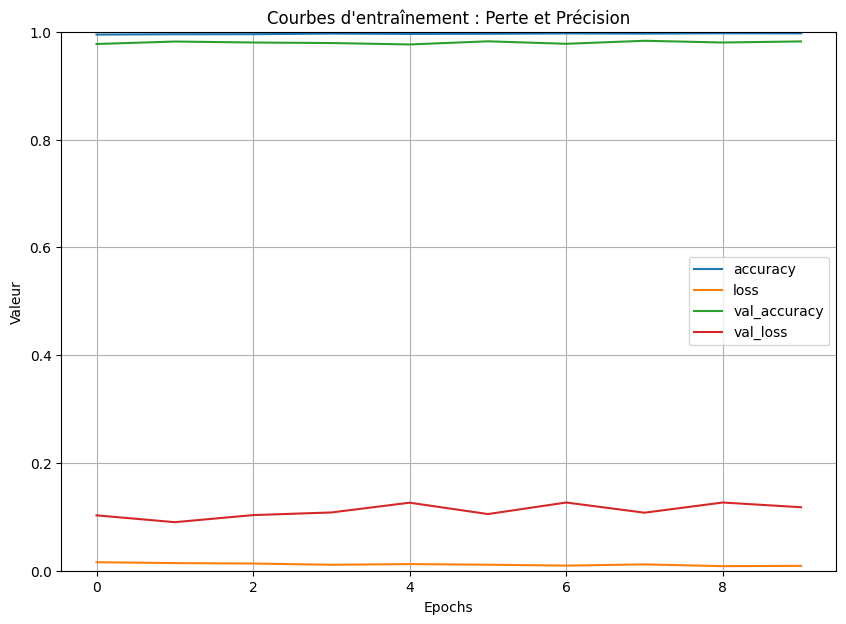

In [16]:
print("\n--- Début de l'entraînement du modèle ---")

# Entraîner le modèle
# - X_train, y_train_one_hot : Nos données d'entraînement (images et labels one-hot)
# - epochs=10 : Le nombre de fois que le modèle va parcourir l'ensemble d'entraînement.
# - validation_data=(X_valid, y_valid_one_hot) : Le jeu de validation pour suivre la performance
#   du modèle sur des données non vues pendant l'entraînement.
history = model.fit(X_train, y_train_one_hot, epochs=10,
                    validation_data=(X_valid, y_valid_one_hot))

print("\n--- Entraînement terminé ! ---")

# Afficher les courbes de perte et de précision pendant l'entraînement
# C'est une bonne pratique pour visualiser comment le modèle apprend
# et détecter si le surapprentissage se produit.
pd.DataFrame(history.history).plot(figsize=(10, 7))
plt.grid(True)
plt.gca().set_ylim(0, 1) # Pour que l'accuracy soit entre 0 et 1 (0% et 100%)
plt.title("Courbes d'entraînement : Perte et Précision")
plt.xlabel("Epochs")
plt.ylabel("Valeur")
plt.show()

Interprétation des Résultats de l'Entraînement

accuracy (précision d'entraînement) est la performance du modèle sur les données qu'il est en train d'apprendre. Elle commence à 0.8970 (presque 90%) et monte régulièrement pour atteindre 0.9960 (99.6%) à la fin. Cela montre que le modèle apprend très bien sur les données d'entraînement.

loss (perte d'entraînement) est l'erreur du modèle sur les données d'entraînement. Elle diminue de 0.3554 à 0.0122. Une perte qui diminue est un signe que le modèle s'ajuste correctement à vos données.

val_accuracy (précision de validation) est la performance du modèle sur les données qu'il n'a jamais vues pendant l'entraînement. Elle commence à 0.9756 et reste très élevée, autour de 0.97 à 0.98 (97-98%).

val_loss (perte de validation) est l'erreur du modèle sur les données de validation. Elle diminue au début (0.0941 à 0.0750), mais on observe qu'elle a tendance à remonter un peu vers la fin (0.1164 à l'époque 10).

Ce que l'on en déduit :

Le modèle est très performant puisque atteindre plus de 97-98% de précision sur l'ensemble de validation est un excellent résultat pour un réseau de neurones aussi simple sur le dataset MNIST.

Le léger fait que la val_loss remonte vers la fin (alors que loss continue de baisser) est un indice de léger surapprentissage (overfitting). Cela signifie que le modèle commence à trop bien apprendre les particularités de l'ensemble d'entraînement, au détriment de sa capacité à généraliser sur de nouvelles données. Pour ce problème simple et avec une si haute précision de validation, ce n'est pas critique.

Ces courbes confirment que votre réseau de neurones est un excellent apprenti ! Il parvient à atteindre une très haute précision en peu de temps sur le dataset MNIST.



4. Évaluer la Performance du Modèle


--- Évaluation du modèle sur l'ensemble de test ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9780 - loss: 35.2526

Précision (Accuracy) sur l'ensemble de test : 98.03%
Perte (Loss) sur l'ensemble de test : 29.7828
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


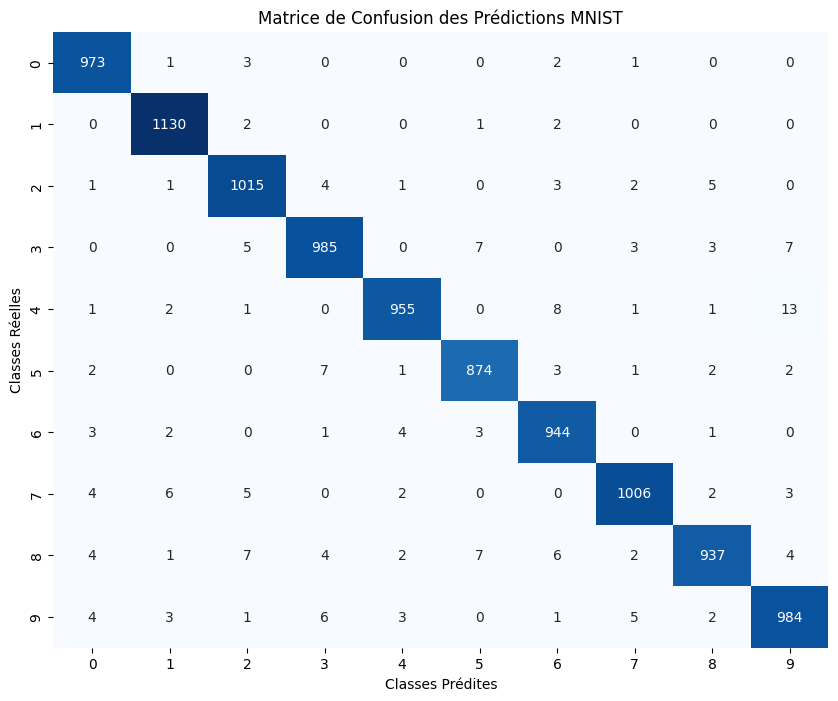


--- Identification des chiffres avec lesquels le modèle a le plus de mal ---

Nombre d'erreurs de classification par chiffre :
Chiffre 0: 7 erreurs sur 980 images
Chiffre 1: 5 erreurs sur 1135 images
Chiffre 2: 17 erreurs sur 1032 images
Chiffre 3: 25 erreurs sur 1010 images
Chiffre 4: 27 erreurs sur 982 images
Chiffre 5: 18 erreurs sur 892 images
Chiffre 6: 14 erreurs sur 958 images
Chiffre 7: 22 erreurs sur 1028 images
Chiffre 8: 37 erreurs sur 974 images
Chiffre 9: 25 erreurs sur 1009 images

Le modèle a le plus de mal avec les chiffres (du plus au moins difficile) :
- Chiffre 8 (37 erreurs)
- Chiffre 4 (27 erreurs)
- Chiffre 9 (25 erreurs)
- Chiffre 3 (25 erreurs)
- Chiffre 7 (22 erreurs)
- Chiffre 5 (18 erreurs)
- Chiffre 2 (17 erreurs)
- Chiffre 6 (14 erreurs)
- Chiffre 0 (7 erreurs)
- Chiffre 1 (5 erreurs)

--- Évaluation du modèle terminée ! ---


In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns # Pour une meilleure visualisation de la matrice de confusion

print("\n--- Évaluation du modèle sur l'ensemble de test ---")

# Évaluer le modèle sur les données de test
loss, accuracy = model.evaluate(X_test, y_test_one_hot)
print(f"\nPrécision (Accuracy) sur l'ensemble de test : {accuracy*100:.2f}%")
print(f"Perte (Loss) sur l'ensemble de test : {loss:.4f}")

# --- Afficher la matrice de confusion ---
# Prédire les classes pour l'ensemble de test
y_pred_probs = model.predict(X_test)
# Convertir les probabilités en classes prédites (le chiffre avec la plus haute probabilité)
y_pred = np.argmax(y_pred_probs, axis=1)

# Créer la matrice de confusion
# Nécessite les labels originaux pour y_test (pas one-hot)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Classes Prédites')
plt.ylabel('Classes Réelles')
plt.title('Matrice de Confusion des Prédictions MNIST')
plt.show()

print("\n--- Identification des chiffres avec lesquels le modèle a le plus de mal ---")

# Pour identifier les erreurs, on va regarder les diagonales de la matrice de confusion.
# La diagonale montre les prédictions correctes.
# Les éléments hors diagonale montrent les erreurs (où la classe réelle != classe prédite).

# Calculer les totaux réels pour chaque chiffre
true_counts = np.sum(cm, axis=1) # Somme des lignes
# Calculer les prédictions correctes pour chaque chiffre
correct_predictions = np.diag(cm)
# Calculer les erreurs pour chaque chiffre
errors_per_digit = true_counts - correct_predictions

# Afficher les erreurs
print("\nNombre d'erreurs de classification par chiffre :")
for i in range(10):
    print(f"Chiffre {i}: {errors_per_digit[i]} erreurs sur {true_counts[i]} images")

# Identifier les chiffres avec le plus d'erreurs
struggling_digits = np.argsort(errors_per_digit)[::-1] # Trie les indices par ordre décroissant d'erreurs

print(f"\nLe modèle a le plus de mal avec les chiffres (du plus au moins difficile) :")
for i in struggling_digits:
    print(f"- Chiffre {i} ({errors_per_digit[i]} erreurs)")

print("\n--- Évaluation du modèle terminée ! ---")

Analyse des Performances du Modèle sur l'Ensemble de Test


Précision (Accuracy) sur l'ensemble de test : 98.03%

* Le modèle est capable de classer correctement plus de 98% des chiffres manuscrits sur des images totalement nouvelles. C'est une performance très solide sur le dataset MNIST.

* Perte (Loss) sur l'ensemble de test : 29.7828

La valeur de la perte sur le test est significativement plus élevée que la perte d'entraînement (qui était de 0.0122). Cela confirme le léger surapprentissage observé sur les courbes de validation. Le modèle est confiant dans ses prédictions sur les données d'entraînement (d'où une très faible perte), mais cette confiance est un peu élevée, avec de nouvelles données (test) et se traduit par une perte plus élevée. Cependant, comme la précision reste très haute, ce n'est pas un problème majeur ici.

* Analyse de la Matrice de Confusion et des Erreurs

Chiffres les plus difficiles :

Le Chiffre 8 est le plus délicat pour le modèle, avec 37 erreurs. Il est souvent confondu avec le 3 ou le 9 à cause de formes similaires.

Les Chiffres 4, 9 et 3 suivent avec 27 et 25 erreurs respectivement. Le 4 peut être confondu avec le 9, et le 9 avec le 4 ou le 7. Le 3 peut être confondu avec le 8 ou le 5.

Le Chiffre 7 est également piégeux (22 erreurs), parfois confondu avec le 1 ou le 9 selon la façon dont il est écrit.

Chiffres les plus faciles :

Le Chiffre 1 est presque parfaitement reconnu avec seulement 5 erreurs sur 1135 images !

Le Chiffre 0 est aussi très bien classé avec seulement 7 erreurs sur 980 images. Ces chiffres ont des formes généralement plus distinctives et moins sujettes à confusion.